# OFDM Comparison: SISO vs STBC vs SFBC

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sionna as sn
import tensorflow as tf
from IPython.display import display
from sionna.phy.channel import cir_to_ofdm_channel, subcarrier_frequencies

np.random.seed(7)
tf.random.set_seed(7)

In [12]:
CARRIER_FREQUENCY_HZ = 3.5e9
FFT_SIZE = 64
NUM_OFDM_SYMBOLS = 64
SUBCARRIER_SPACING_HZ = 15e3
CYCLIC_PREFIX_LENGTH = 8
LOW_DELAY_SPREAD_S = 200e-9
HIGH_DELAY_SPREAD_S = 4.0e-6
BITS_PER_SYMBOL = 2
CODE_RATE = 1.0
FRAME_BITS = FFT_SIZE * NUM_OFDM_SYMBOLS * BITS_PER_SYMBOL
FRAMES_PER_BATCH = 64
TARGET_BITS_PER_EBNO = 1000000
NUM_MONTE_CARLO_TRIALS = 3
EBNO_DB_VALUES = np.arange(-1.0, 21.0, 1.0, dtype=np.float32)
PREVIEW_SYMBOLS = 6
PREVIEW_SUBCARRIERS = 8

In [13]:
ALAMOUTI_TX_SCALE = tf.cast(1.0 / np.sqrt(2.0), tf.complex64)
SQRT2_COMPLEX = tf.cast(np.sqrt(2.0), tf.complex64)
EPSILON = tf.complex(tf.constant(1e-9, dtype=tf.float32), tf.constant(0.0, dtype=tf.float32))

In [14]:
USEFUL_SYMBOL_DURATION_S = 1.0 / SUBCARRIER_SPACING_HZ
SAMPLE_PERIOD_S = USEFUL_SYMBOL_DURATION_S / FFT_SIZE
CP_DURATION_S = CYCLIC_PREFIX_LENGTH * SAMPLE_PERIOD_S
OFDM_SYMBOL_DURATION_S = USEFUL_SYMBOL_DURATION_S + CP_DURATION_S
OFDM_SYMBOL_RATE_HZ = 1.0 / OFDM_SYMBOL_DURATION_S
FREQUENCIES_HZ = subcarrier_frequencies(FFT_SIZE, SUBCARRIER_SPACING_HZ)

assert LOW_DELAY_SPREAD_S < CP_DURATION_S
assert HIGH_DELAY_SPREAD_S < CP_DURATION_S

### Setup different wireless environments

In [46]:
CHANNEL_CASES = {
    "Low Delay Low Doppler": {
        "delay_spread_s": LOW_DELAY_SPREAD_S,
        "speed_m_per_s": 3.0,
        "tdl_model": "A",
    },
    "High Delay Low Doppler": {
        "delay_spread_s": HIGH_DELAY_SPREAD_S,
        "speed_m_per_s": 3.0,
        "tdl_model": "A",
    },
    "Low Delay High Doppler": {
        "delay_spread_s": LOW_DELAY_SPREAD_S,
        "speed_m_per_s": 50.0,
        "tdl_model": "A",
    },
    "High Delay High Doppler": {
        "delay_spread_s": HIGH_DELAY_SPREAD_S,
        "speed_m_per_s": 50.0,
        "tdl_model": "A",
    },
}

case_rows = []
for case_name, case_config in CHANNEL_CASES.items():
    max_doppler_hz = case_config["speed_m_per_s"] * CARRIER_FREQUENCY_HZ / 3e8
    case_rows.append(
        {
            "case": case_name,
            "delay_spread_s": case_config["delay_spread_s"],
            "cp_duration_s": CP_DURATION_S,
            "cp_margin_s": CP_DURATION_S - case_config["delay_spread_s"],
            "cp_safe": case_config["delay_spread_s"] < CP_DURATION_S,
            "speed_m_per_s": case_config["speed_m_per_s"],
            "approx_max_doppler_hz": max_doppler_hz,
            "tdl_model": case_config["tdl_model"],
        }
    )

case_table = pd.DataFrame(case_rows)
assert bool(case_table["cp_safe"].all())
display(case_table)

,case,delay_spread_s,cp_duration_s,cp_margin_s,cp_safe,speed_m_per_s,approx_max_doppler_hz,tdl_model
0,Low Delay Low Doppler,2.000000e-07,0.000008,0.000008,True,3.0,35.000000,A
1,High Delay Low Doppler,4.000000e-06,0.000008,0.000004,True,3.0,35.000000,A
2,Low Delay High Doppler,2.000000e-07,0.000008,0.000008,True,50.0,583.333333,A
3,High Delay High Doppler,4.000000e-06,0.000008,0.000004,True,50.0,583.333333,A


In [ ]:
#Sionna setup
constellation = sn.phy.mapping.Constellation("qam", BITS_PER_SYMBOL)
mapper = sn.phy.mapping.Mapper(constellation=constellation)
demapper = sn.phy.mapping.Demapper("app", constellation=constellation)
binary_source = sn.phy.mapping.BinarySource()
awgn = sn.phy.channel.AWGN()

LDPC_CODE_RATE = 0.5
LDPC_CODEWORD_BITS = FRAME_BITS
LDPC_INFO_BITS = int(LDPC_CODEWORD_BITS * LDPC_CODE_RATE)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning, module="sionna.phy.fec.ldpc.encoding")
    ldpc_encoder = sn.phy.fec.ldpc.encoding.LDPC5GEncoder(LDPC_INFO_BITS, LDPC_CODEWORD_BITS)
ldpc_decoder = sn.phy.fec.ldpc.decoding.LDPC5GDecoder(
    ldpc_encoder,
    hard_out=True,
    return_infobits=True,
)



QPSK_REFERENCE_BITS = tf.constant([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=tf.int32)
QPSK_REFERENCE_SYMBOLS = tf.cast(
    tf.reshape(mapper(tf.reshape(QPSK_REFERENCE_BITS, [1, -1])), [4]),
    tf.complex64,
)

#Transceiver components
def generate_qpsk_grid(batch_size):
    """Generate random uncoded QPSK symbols on a full OFDM grid with Sionna blocks."""
    tx_bits = tf.cast(binary_source([batch_size, FRAME_BITS]), tf.int32)
    tx_symbols = tf.cast(mapper(tx_bits), tf.complex64)
    tx_grid = tf.reshape(tx_symbols, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE])
    return tx_bits, tx_grid


def compute_noise_variance(ebno_db):
    """Return the noise variance that corresponds to the requested Eb/No."""
    ## need to update this to ofdm noise - scale by number of active subcarriers and also the cyclic prefix 
    return tf.cast(sn.phy.utils.ebnodb2no(ebno_db, BITS_PER_SYMBOL, CODE_RATE), tf.float32)


def ml_detect_qpsk(equalized_grid):
    """Perform symbol-wise ML detection over the four QPSK constellation points for an AWGN channel"""
    distances = tf.abs(equalized_grid[..., tf.newaxis] - QPSK_REFERENCE_SYMBOLS) ** 2
    decision_indices = tf.argmin(distances, axis=-1, output_type=tf.int32)
    detected_symbols = tf.gather(QPSK_REFERENCE_SYMBOLS, decision_indices)
    detected_bits = tf.gather(QPSK_REFERENCE_BITS, decision_indices)
    detected_bits = tf.reshape(detected_bits, [tf.shape(equalized_grid)[0], -1])
    return tf.cast(detected_bits, tf.int32), detected_symbols

#Channel components - first get the channel impulse response, and then convert to the frequency response
def build_tdl_model(case_config):
    """Instantiate one Sionna TDL model for a specific delay-Doppler case."""
    return sn.phy.channel.tr38901.TDL(
        model=case_config["tdl_model"],
        delay_spread=case_config["delay_spread_s"],
        carrier_frequency=CARRIER_FREQUENCY_HZ,
        min_speed=case_config["speed_m_per_s"],
        max_speed=case_config["speed_m_per_s"],
    )


def generate_independent_ofdm_channels(case_config, batch_size, num_tx_branches):
    """Generate independent TDL-based OFDM channel responses for each transmit branch."""
    h_branches = []
    for _ in range(num_tx_branches):
        tdl_model = build_tdl_model(case_config)
        a, tau = tdl_model(batch_size, NUM_OFDM_SYMBOLS, OFDM_SYMBOL_RATE_HZ)
        h_freq = cir_to_ofdm_channel(FREQUENCIES_HZ, a, tau, normalize=True)
        h_branch = tf.cast(h_freq[:, 0, 0, 0, 0, :, :], tf.complex64)
        h_branches.append(h_branch)
    return tf.stack(h_branches, axis=1)

In [ ]:
def plot_time_frequency_surface(ax, h_tf_mag, title):
    """Render one 3D time-frequency magnitude surface."""
    n_sym, n_sub = h_tf_mag.shape
    x_grid, y_grid = np.meshgrid(np.arange(n_sub), np.arange(n_sym))
    ax.plot_surface(x_grid, y_grid, h_tf_mag, cmap="viridis", linewidth=0, antialiased=True)
    ax.set_xlabel("Subcarrier Index")
    ax.set_ylabel("OFDM Symbol Index")
    ax.set_zlabel("|h_tf|")
    ax.set_title(title, pad=16)


def plot_case_channel_surfaces(case_name, h_branches):
    """Plot each independent 3D time-frequency channel response."""
    h_np = np.abs(h_branches[0].numpy())
    num_plots = h_np.shape[0]
    for branch_idx in range(num_plots):
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(1, 1, 1, projection="3d")
        plot_time_frequency_surface(ax, h_np[branch_idx], "3D time-frequency channel magnitude\n", f"{format_case_title(case_name)}\n", f"Tx {branch_idx + 1}")
        plt.tight_layout()
        plt.show()

In [69]:
def siso_ofdm_batch(ebno_db, case_config, batch_size=FRAMES_PER_BATCH, return_details=False):
    """Simulate one batch of uncoded SISO OFDM with exact CSI and ML QPSK detection."""
    tx_bits, tx_grid = generate_qpsk_grid(batch_size)
    h_branches = generate_independent_ofdm_channels(case_config, batch_size, num_tx_branches=1)
    h = h_branches[:, 0, :, :]
    no = compute_noise_variance(ebno_db)
    y_noiseless = h * tx_grid
    y = awgn(y_noiseless, no)
    x_hat = y / (h + EPSILON)
    rx_bits, rx_symbols = ml_detect_qpsk(x_hat)
    if not return_details:
        return tx_bits, rx_bits, h_branches
    details = {
        "tx_bits": tx_bits,
        "tx_grid": tx_grid,
        "h_branches": h_branches,
        "y": y,
        "x_hat": x_hat,
        "rx_symbols": rx_symbols,
    }
    return tx_bits, rx_bits, h_branches, details


def equalize_alamouti_pairs(h10, h11, h20, h21, y0, y1):
    """Equalize one Alamouti pair without assuming the channel is constant over the pair."""
    z0 = tf.math.conj(h10) * y0 + h21 * tf.math.conj(y1)
    z1 = tf.math.conj(h20) * y0 - h11 * tf.math.conj(y1)
    gram00 = tf.abs(h10) ** 2 + tf.abs(h21) ** 2
    gram11 = tf.abs(h20) ** 2 + tf.abs(h11) ** 2
    gram01 = tf.math.conj(h10) * h20 - h21 * tf.math.conj(h11)
    det = gram00 * gram11 - tf.abs(gram01) ** 2 + 1e-9
    det_complex = tf.cast(det, tf.complex64)
    gram00_complex = tf.cast(gram00, tf.complex64)
    gram11_complex = tf.cast(gram11, tf.complex64)
    s0_hat = SQRT2_COMPLEX * (gram11_complex * z0 - gram01 * z1) / det_complex
    s1_hat = SQRT2_COMPLEX * (gram00_complex * z1 - tf.math.conj(gram01) * z0) / det_complex
    return z0, z1, s0_hat, s1_hat, gram00, gram11, det


def stbc_ofdm_batch(ebno_db, case_config, batch_size=FRAMES_PER_BATCH, return_details=False):
    """Simulate one batch of 2x1 Alamouti STBC OFDM with exact CSI and ML QPSK detection."""
    tx_bits, tx_grid = generate_qpsk_grid(batch_size)
    h_branches = generate_independent_ofdm_channels(case_config, batch_size, num_tx_branches=2)
    h1 = h_branches[:, 0, :, :]
    h2 = h_branches[:, 1, :, :]
    tx_pairs = tf.reshape(tx_grid, [batch_size, NUM_OFDM_SYMBOLS // 2, 2, FFT_SIZE])
    s0 = tx_pairs[:, :, 0, :]
    s1 = tx_pairs[:, :, 1, :]
    x1_pairs = ALAMOUTI_TX_SCALE * tf.stack([s0, -tf.math.conj(s1)], axis=2)
    x2_pairs = ALAMOUTI_TX_SCALE * tf.stack([s1, tf.math.conj(s0)], axis=2)
    x1 = tf.reshape(x1_pairs, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE])
    x2 = tf.reshape(x2_pairs, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE])
    no = compute_noise_variance(ebno_db)
    y_noiseless = h1 * x1 + h2 * x2
    y = awgn(y_noiseless, no)
    h1_pairs = tf.reshape(h1, [batch_size, NUM_OFDM_SYMBOLS // 2, 2, FFT_SIZE])
    h2_pairs = tf.reshape(h2, [batch_size, NUM_OFDM_SYMBOLS // 2, 2, FFT_SIZE])
    y_pairs = tf.reshape(y, [batch_size, NUM_OFDM_SYMBOLS // 2, 2, FFT_SIZE])
    h10 = h1_pairs[:, :, 0, :]
    h11 = h1_pairs[:, :, 1, :]
    h20 = h2_pairs[:, :, 0, :]
    h21 = h2_pairs[:, :, 1, :]
    y0 = y_pairs[:, :, 0, :]
    y1 = y_pairs[:, :, 1, :]
    z0, z1, s0_hat, s1_hat, _, _, _ = equalize_alamouti_pairs(h10, h11, h20, h21, y0, y1)
    x_hat_pairs = tf.stack([s0_hat, s1_hat], axis=2)
    x_hat = tf.reshape(x_hat_pairs, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE])
    rx_bits, rx_symbols = ml_detect_qpsk(x_hat)
    if not return_details:
        return tx_bits, rx_bits, h_branches
    details = {
        "tx_bits": tx_bits,
        "tx_grid": tx_grid,
        "h_branches": h_branches,
        "tx_pairs": tx_pairs,
        "s0": s0,
        "s1": s1,
        "x1_pairs": x1_pairs,
        "x2_pairs": x2_pairs,
        "x1": x1,
        "x2": x2,
        "y": y,
        "y_pairs": y_pairs,
        "z0": z0,
        "z1": z1,
        "s0_hat": s0_hat,
        "s1_hat": s1_hat,
        "x_hat": x_hat,
        "rx_symbols": rx_symbols,
    }
    return tx_bits, rx_bits, h_branches, details


def sfbc_ofdm_batch(ebno_db, case_config, batch_size=FRAMES_PER_BATCH, return_details=False):
    """Simulate one batch of 2x1 Alamouti SFBC OFDM with exact CSI and ML QPSK detection."""
    tx_bits, tx_grid = generate_qpsk_grid(batch_size)
    h_branches = generate_independent_ofdm_channels(case_config, batch_size, num_tx_branches=2)
    h1 = h_branches[:, 0, :, :]
    h2 = h_branches[:, 1, :, :]
    tx_pairs = tf.reshape(tx_grid, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE // 2, 2])
    s0 = tx_pairs[:, :, :, 0]
    s1 = tx_pairs[:, :, :, 1]
    x1_pairs = ALAMOUTI_TX_SCALE * tf.stack([s0, -tf.math.conj(s1)], axis=3)
    x2_pairs = ALAMOUTI_TX_SCALE * tf.stack([s1, tf.math.conj(s0)], axis=3)
    x1 = tf.reshape(x1_pairs, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE])
    x2 = tf.reshape(x2_pairs, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE])
    no = compute_noise_variance(ebno_db)
    y_noiseless = h1 * x1 + h2 * x2
    y = awgn(y_noiseless, no)
    h1_pairs = tf.reshape(h1, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE // 2, 2])
    h2_pairs = tf.reshape(h2, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE // 2, 2])
    y_pairs = tf.reshape(y, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE // 2, 2])
    h10 = h1_pairs[:, :, :, 0]
    h11 = h1_pairs[:, :, :, 1]
    h20 = h2_pairs[:, :, :, 0]
    h21 = h2_pairs[:, :, :, 1]
    y0 = y_pairs[:, :, :, 0]
    y1 = y_pairs[:, :, :, 1]
    z0, z1, s0_hat, s1_hat, _, _, _ = equalize_alamouti_pairs(h10, h11, h20, h21, y0, y1)
    x_hat_pairs = tf.stack([s0_hat, s1_hat], axis=3)
    x_hat = tf.reshape(x_hat_pairs, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE])
    rx_bits, rx_symbols = ml_detect_qpsk(x_hat)
    if not return_details:
        return tx_bits, rx_bits, h_branches
    details = {
        "tx_bits": tx_bits,
        "tx_grid": tx_grid,
        "h_branches": h_branches,
        "tx_pairs": tx_pairs,
        "s0": s0,
        "s1": s1,
        "x1_pairs": x1_pairs,
        "x2_pairs": x2_pairs,
        "x1": x1,
        "x2": x2,
        "y": y,
        "y_pairs": y_pairs,
        "z0": z0,
        "z1": z1,
        "s0_hat": s0_hat,
        "s1_hat": s1_hat,
        "x_hat": x_hat,
        "rx_symbols": rx_symbols,
    }
    return tx_bits, rx_bits, h_branches, details

In [ ]:
SCHEME_FUNCTIONS = {
    "SISO": siso_ofdm_batch,
    "STBC 2x1 Alamouti": stbc_ofdm_batch,
    "SFBC 2x1 Alamouti": sfbc_ofdm_batch,
}

CASE_TITLE_LABELS = {
    "Low Delay Low Doppler": "Low delay spread, low Doppler spread channel",
    "High Delay Low Doppler": "High delay spread, low Doppler spread channel",
    "Low Delay High Doppler": "Low delay spread, high Doppler spread channel",
    "High Delay High Doppler": "High delay spread, high Doppler spread channel",
}


def compute_bit_error_statistics(tx_bits, rx_bits):
    """Compute BER numerators and denominators for one batch."""
    bit_error_tensor = tf.not_equal(tx_bits, rx_bits)
    bit_errors = int(tf.reduce_sum(tf.cast(bit_error_tensor, tf.int64)).numpy())
    total_bits = int(np.prod(tx_bits.shape))
    return bit_errors, total_bits


def compute_symbol_error_statistics(tx_symbols, rx_symbols):
    """Compute SER numerators and denominators for one batch."""
    tx_symbol_tensor = tf.reshape(tf.cast(tx_symbols, tf.complex64), [tf.shape(tx_symbols)[0], -1])
    rx_symbol_tensor = tf.reshape(tf.cast(rx_symbols, tf.complex64), [tf.shape(rx_symbols)[0], -1])
    symbol_error_tensor = tf.not_equal(tx_symbol_tensor, rx_symbol_tensor)
    symbol_errors = int(tf.reduce_sum(tf.cast(symbol_error_tensor, tf.int64)).numpy())
    total_symbols = int(tf.size(tx_symbols).numpy())
    return symbol_errors, total_symbols


def simulate_scheme_curve(scheme_name, case_name, case_config, ebno_values=EBNO_DB_VALUES):
    """Run averaged BER and SER curves for one scheme and one channel case."""
    scheme_fn = SCHEME_FUNCTIONS[scheme_name]
    rows = []
    for ebno_db in ebno_values:
        trial_ber_values = []
        trial_ser_values = []
        trial_total_bits = []
        trial_total_symbols = []
        for trial_idx in range(NUM_MONTE_CARLO_TRIALS):
            bit_errors = 0
            symbol_errors = 0
            total_bits = 0
            total_symbols = 0
            while total_bits < TARGET_BITS_PER_EBNO:
                tx_bits, rx_bits, _, details = scheme_fn(
                    float(ebno_db),
                    case_config,
                    batch_size=FRAMES_PER_BATCH,
                    return_details=True,
                )
                cur_bit_errors, cur_total_bits = compute_bit_error_statistics(tx_bits, rx_bits)
                cur_symbol_errors, cur_total_symbols = compute_symbol_error_statistics(
                    details["tx_grid"],
                    details["rx_symbols"],
                )
                bit_errors += cur_bit_errors
                symbol_errors += cur_symbol_errors
                total_bits += cur_total_bits
                total_symbols += cur_total_symbols
            trial_ber = bit_errors / total_bits
            trial_ser = symbol_errors / total_symbols
            trial_ber_values.append(trial_ber)
            trial_ser_values.append(trial_ser)
            trial_total_bits.append(total_bits)
            trial_total_symbols.append(total_symbols)
        rows.append(
            {
                "scheme": scheme_name,
                "case": case_name,
                "ebno_db": float(ebno_db),
                "ber": float(np.mean(trial_ber_values)),
                "ber_std": float(np.std(trial_ber_values)),
                "ser": float(np.mean(trial_ser_values)),
                "ser_std": float(np.std(trial_ser_values)),
                "total_bits_per_trial": int(np.max(trial_total_bits)),
                "total_symbols_per_trial": int(np.max(trial_total_symbols)),
                "mc_trials": NUM_MONTE_CARLO_TRIALS,
            }
        )
    return pd.DataFrame(rows)


def format_case_title(case_name):
    """Return a full textual description for one channel case."""
    return CASE_TITLE_LABELS.get(case_name, f"{case_name} channel")


def plot_case_metric_curves(case_name, case_results, metric_name, ldpc_coded=False):
    """Plot one performance metric for the three schemes in one channel case."""
    metric_label = metric_name.upper()
    title_prefix = "LDPC-coded " if ldpc_coded else ""
    plt.figure(figsize=(8, 5))
    for scheme_name, result_df in case_results.items():
        metric_values = result_df[metric_name].where(result_df[metric_name] > 0.0, np.nan)
        plt.semilogy(result_df["ebno_db"], metric_values, marker="o", label=scheme_name)
    plt.xlabel(r"$E_b/N_0$ [dB]")
    plt.ylabel(metric_label)
    plt.title(f"{title_prefix}{metric_label} performance on a {format_case_title(case_name)}")
    plt.ylim(1e-6, 1.0)
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_case_error_curves(case_name, case_results, ldpc_coded=False):
    """Plot BER and SER comparisons for the three schemes in one channel case."""
    plot_case_metric_curves(case_name, case_results, "ber", ldpc_coded=ldpc_coded)
    plot_case_metric_curves(case_name, case_results, "ser", ldpc_coded=ldpc_coded)

## Channel Visualisation


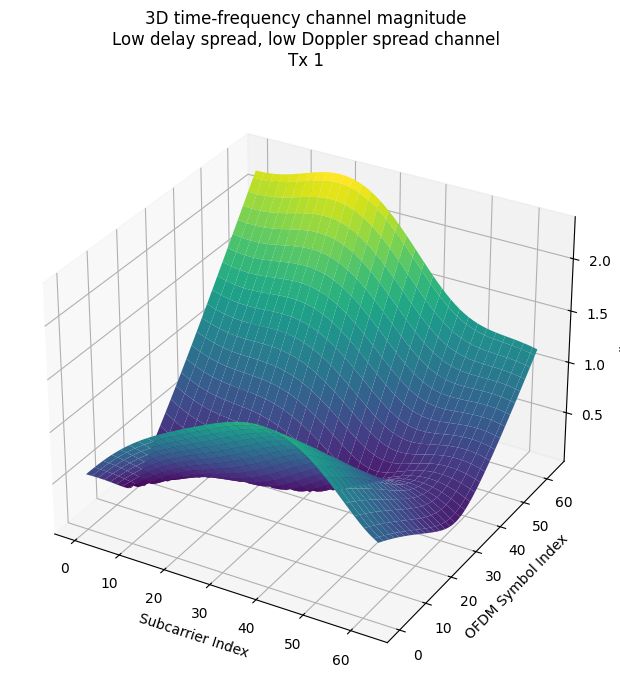

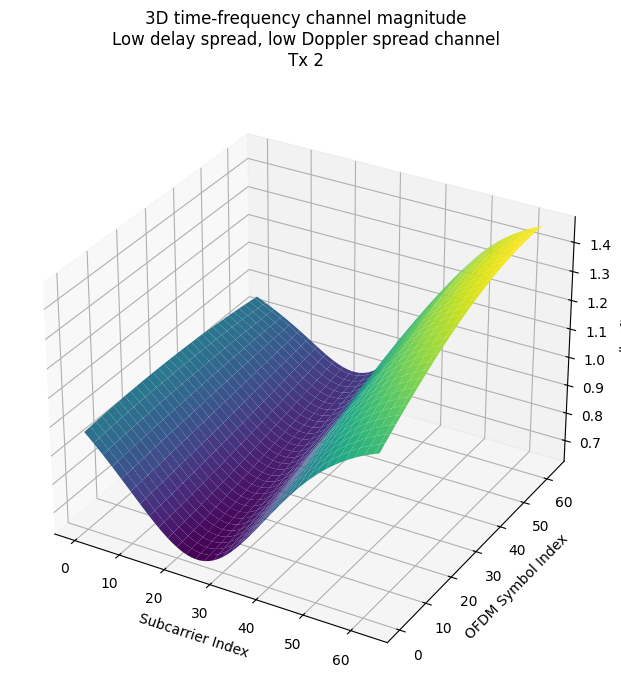

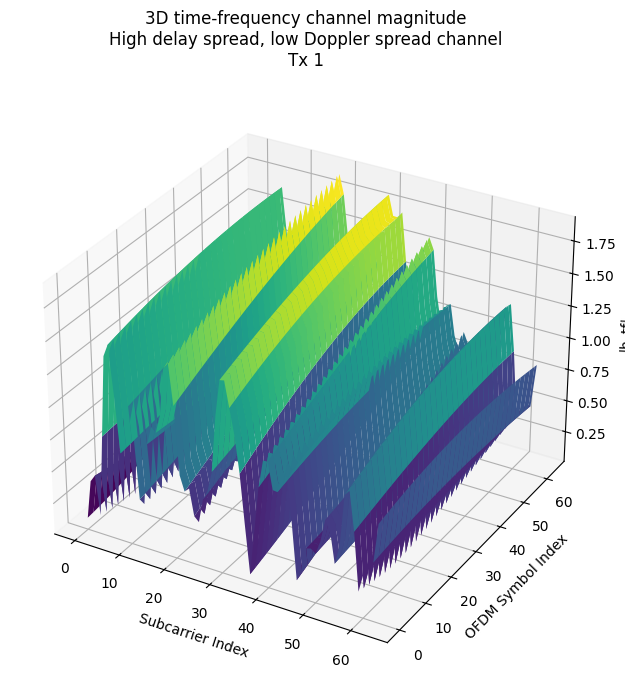

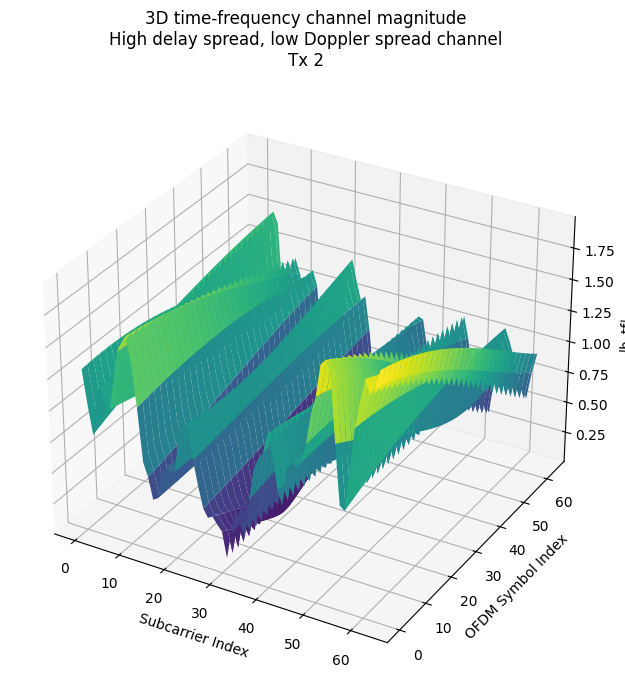

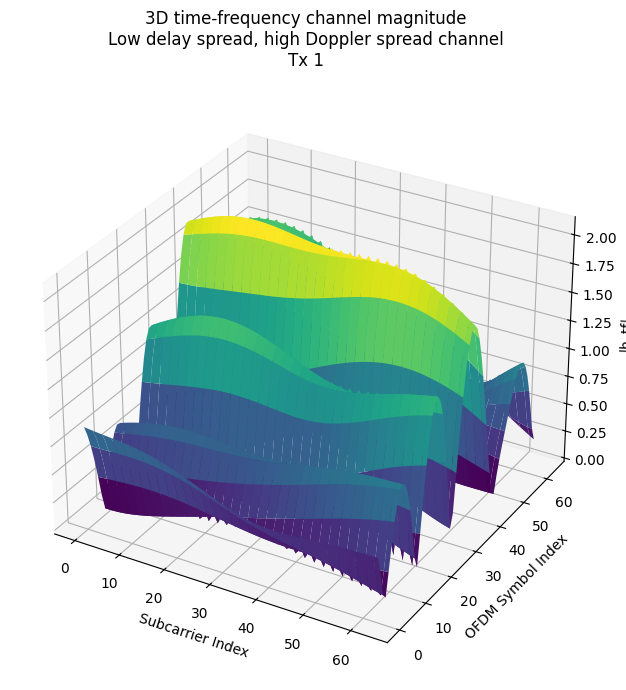

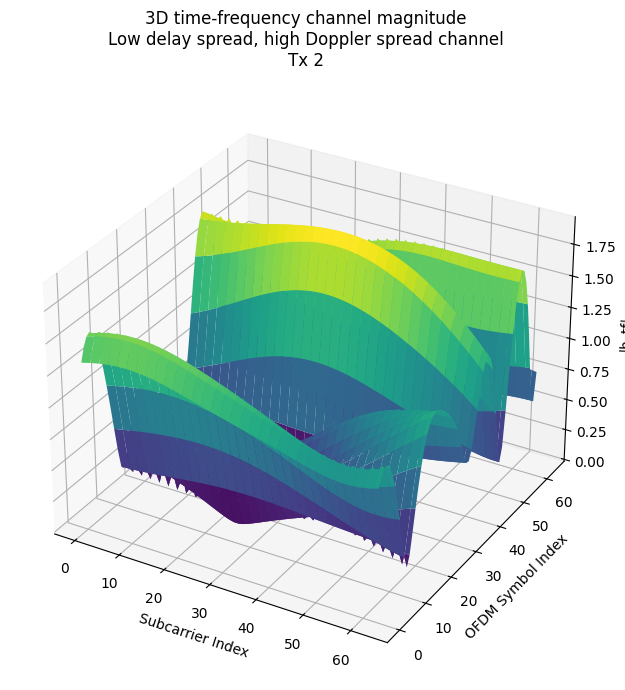

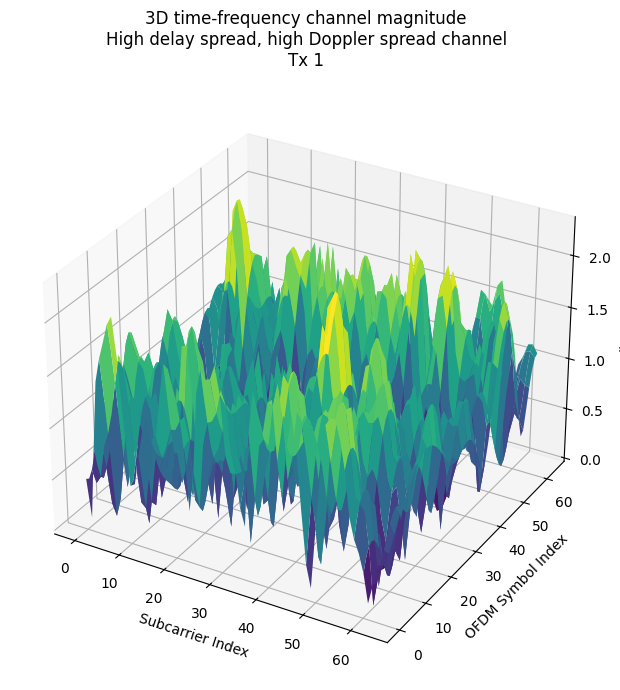

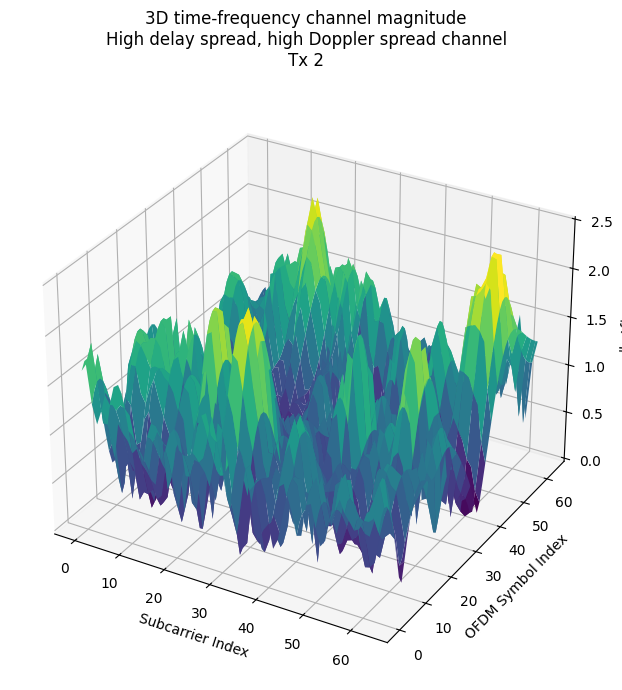

In [66]:
case_channel_catalog = {}

for case_name, case_config in CHANNEL_CASES.items():
    h_case = generate_independent_ofdm_channels(case_config, batch_size=1, num_tx_branches=2)
    case_channel_catalog[case_name] = h_case
    plot_case_channel_surfaces(case_name, h_case)

## BER Simulation

In [73]:
results_by_case = {}

for case_name, case_config in CHANNEL_CASES.items():
    case_results = {}
    for scheme_name in SCHEME_FUNCTIONS:
        case_results[scheme_name] = simulate_scheme_curve(
            scheme_name=scheme_name,
            case_name=case_name,
            case_config=case_config,
        )
    results_by_case[case_name] = case_results

all_results_df = pd.concat(
    [
        result_df
        for case_results in results_by_case.values()
        for result_df in case_results.values()
    ],
    ignore_index=True,
)

display(all_results_df.head())


Running full sweep for: Low Delay Low Doppler
Low Delay Low Doppler | SISO | $E_b/N_0$= -1.0 dB | trial=1/3 | BER=1.284e-01 | SER=2.344e-01
Low Delay Low Doppler | SISO | $E_b/N_0$= -1.0 dB | trial=2/3 | BER=1.302e-01 | SER=2.371e-01
Low Delay Low Doppler | SISO | $E_b/N_0$= -1.0 dB | trial=3/3 | BER=1.318e-01 | SER=2.395e-01
Low Delay Low Doppler | SISO | $E_b/N_0$=  0.0 dB | trial=1/3 | BER=1.075e-01 | SER=1.970e-01
Low Delay Low Doppler | SISO | $E_b/N_0$=  0.0 dB | trial=2/3 | BER=1.063e-01 | SER=1.953e-01
Low Delay Low Doppler | SISO | $E_b/N_0$=  0.0 dB | trial=3/3 | BER=1.038e-01 | SER=1.911e-01
Low Delay Low Doppler | SISO | $E_b/N_0$=  1.0 dB | trial=1/3 | BER=8.105e-02 | SER=1.508e-01
Low Delay Low Doppler | SISO | $E_b/N_0$=  1.0 dB | trial=2/3 | BER=8.162e-02 | SER=1.516e-01
Low Delay Low Doppler | SISO | $E_b/N_0$=  1.0 dB | trial=3/3 | BER=8.257e-02 | SER=1.532e-01
Low Delay Low Doppler | SISO | $E_b/N_0$=  2.0 dB | trial=1/3 | BER=6.366e-02 | SER=1.187e-01
Low Delay Low

,scheme,case,ebno_db,ber,ber_std,ser,ser_std,total_bits_per_trial,total_symbols_per_trial,mc_trials
0,SISO,Low Delay Low Doppler,-1.0,0.130134,0.001353,0.237000,0.002110,1048576,524288,3
1,SISO,Low Delay Low Doppler,0.0,0.105863,0.001506,0.194475,0.002498,1048576,524288,3
2,SISO,Low Delay Low Doppler,1.0,0.081748,0.000625,0.151875,0.000996,1048576,524288,3
3,SISO,Low Delay Low Doppler,2.0,0.065519,0.001961,0.121523,0.003158,1048576,524288,3
4,SISO,Low Delay Low Doppler,3.0,0.051580,0.002402,0.095784,0.004119,1048576,524288,3


## BER Plots

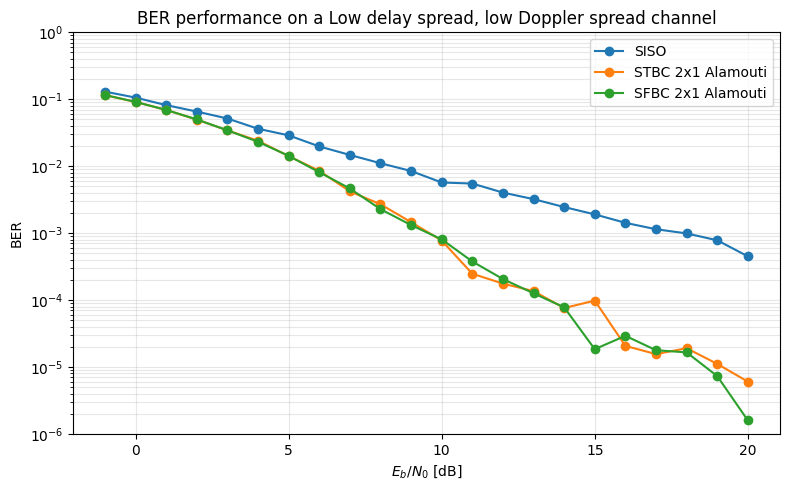

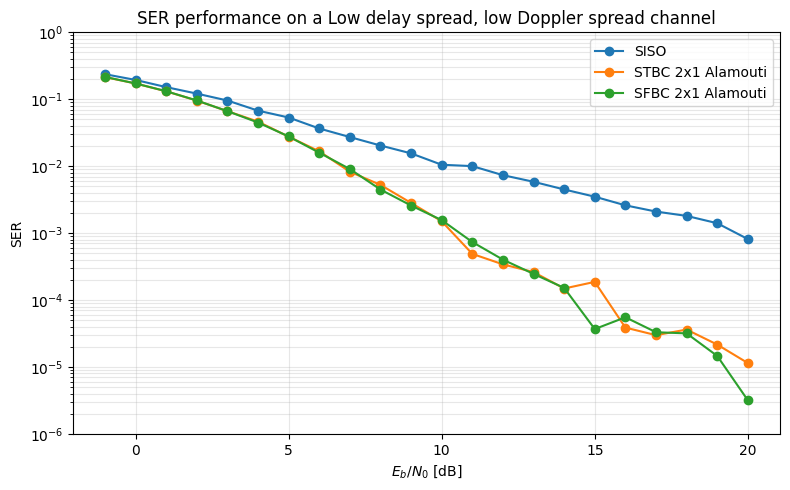

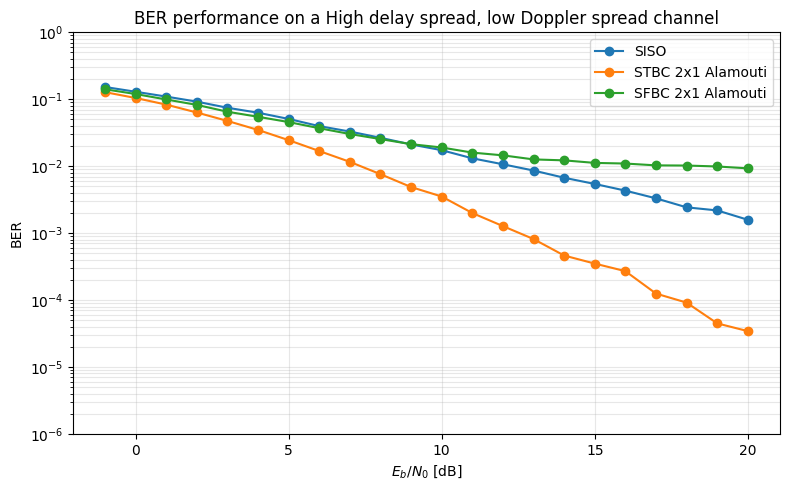

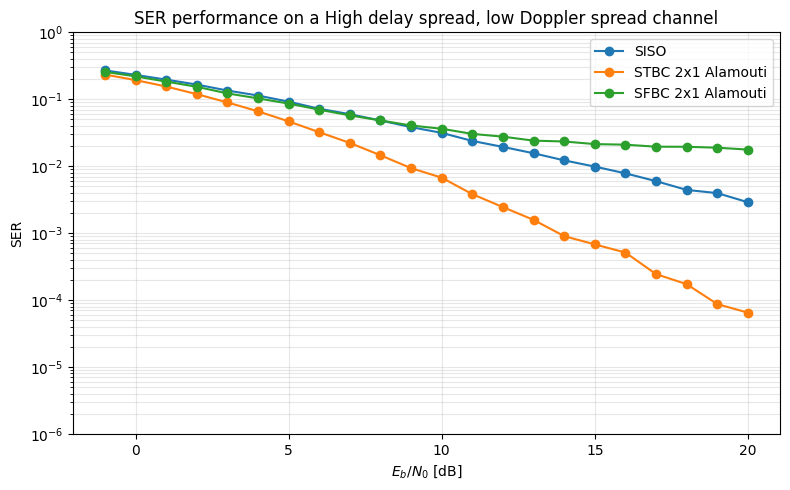

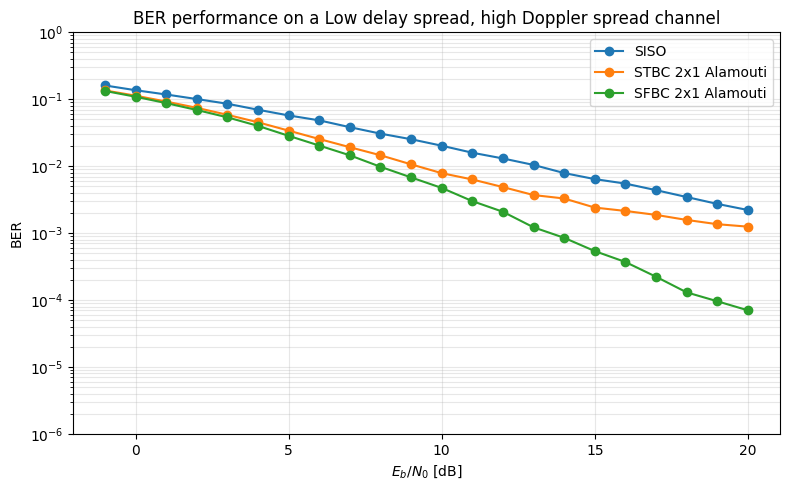

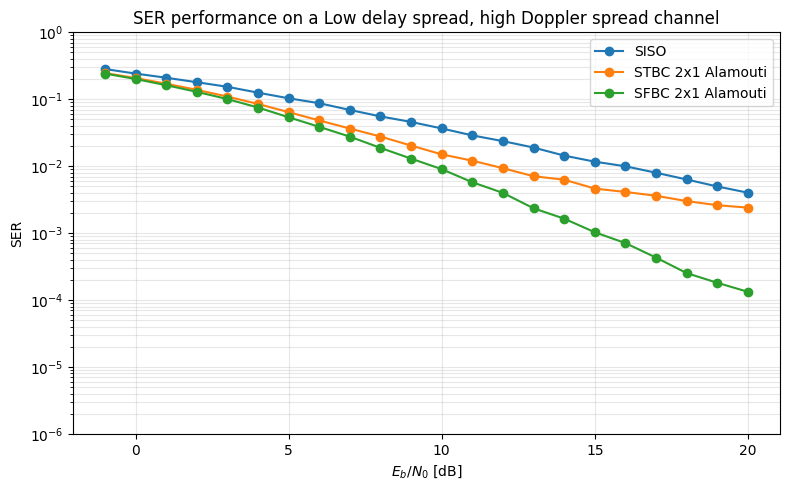

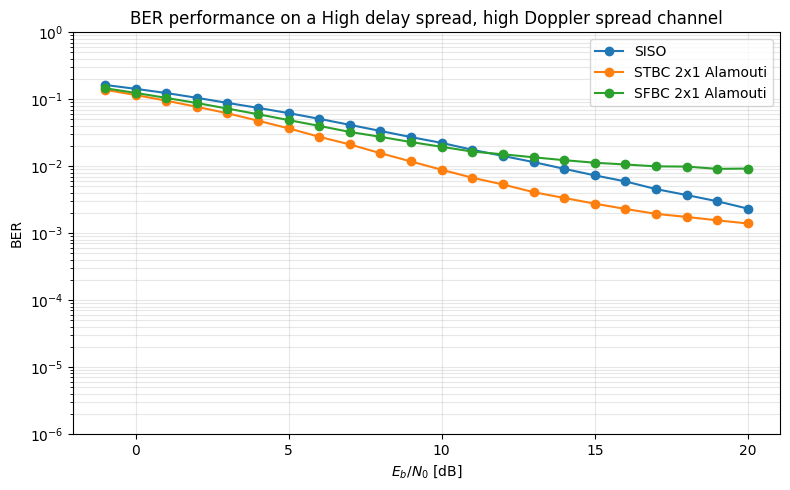

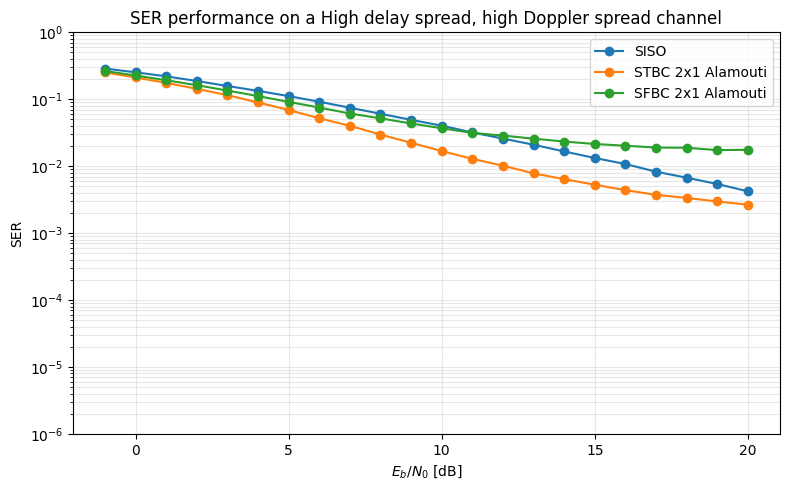

,case,scheme,min_ber,avg_ber_std,min_ser,avg_ser_std,bits_per_trial,symbols_per_trial,mc_trials
0,High Delay High Doppler,SFBC 2x1 Alamouti,0.009127,0.000281,0.017395,0.000494,1048576,524288,3
1,High Delay High Doppler,SISO,0.002323,0.000265,0.004217,0.000433,1048576,524288,3
2,High Delay High Doppler,STBC 2x1 Alamouti,0.001393,0.000202,0.002661,0.000360,1048576,524288,3
3,High Delay Low Doppler,SFBC 2x1 Alamouti,0.009287,0.000588,0.017700,0.001043,1048576,524288,3
4,High Delay Low Doppler,SISO,0.001582,0.000528,0.002896,0.000906,1048576,524288,3
5,High Delay Low Doppler,STBC 2x1 Alamouti,0.000034,0.000269,0.000065,0.000455,1048576,524288,3
6,Low Delay High Doppler,SFBC 2x1 Alamouti,0.000070,0.000326,0.000133,0.000568,1048576,524288,3
7,Low Delay High Doppler,SISO,0.002216,0.000658,0.004020,0.001096,1048576,524288,3
8,Low Delay High Doppler,STBC 2x1 Alamouti,0.001250,0.000373,0.002406,0.000673,1048576,524288,3
9,Low Delay Low Doppler,SFBC 2x1 Alamouti,0.000002,0.000235,0.000003,0.000414,1048576,524288,3


In [74]:
for case_name, case_results in results_by_case.items():
    plot_case_error_curves(case_name, case_results)

summary_table = all_results_df.groupby(["case", "scheme"], as_index=False).agg(
    min_ber=("ber", "min"),
    avg_ber_std=("ber_std", "mean"),
    min_ser=("ser", "min"),
    avg_ser_std=("ser_std", "mean"),
    bits_per_trial=("total_bits_per_trial", "max"),
    symbols_per_trial=("total_symbols_per_trial", "max"),
    mc_trials=("mc_trials", "max"),
)

display(summary_table)

## LDPC-Coded OFDM BER Simulation

This section repeats the same SISO, STBC, and SFBC OFDM experiments, but now the transmitted QPSK symbols are obtained from a rate-1/2 5G LDPC code. The codeword length is fixed to the OFDM frame size of 8192 coded bits, so each frame carries 4096 information bits before LDPC encoding.

In [ ]:
def compute_ldpc_noise_variance(ebno_db):
    """Return the noise variance for the rate-1/2 LDPC-coded link."""
    return tf.cast(sn.phy.utils.ebnodb2no(ebno_db, BITS_PER_SYMBOL, LDPC_CODE_RATE), tf.float32)


def generate_ldpc_qpsk_grid(batch_size):
    """Generate one OFDM grid from information bits, LDPC encoding, and QPSK mapping."""
    info_bits = binary_source([batch_size, LDPC_INFO_BITS])
    coded_bits = ldpc_encoder(info_bits)
    tx_symbols = tf.cast(mapper(coded_bits), tf.complex64)
    tx_grid = tf.reshape(tx_symbols, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE])
    return tf.cast(info_bits, tf.int32), coded_bits, tx_grid


def siso_ofdm_ldpc_batch(ebno_db, case_config, batch_size=FRAMES_PER_BATCH, return_details=False):
    """Simulate one batch of LDPC-coded SISO OFDM with perfect CSI."""
    info_bits, coded_bits, tx_grid = generate_ldpc_qpsk_grid(batch_size)
    h_branches = generate_independent_ofdm_channels(case_config, batch_size, num_tx_branches=1)
    h = h_branches[:, 0, :, :]
    no = compute_ldpc_noise_variance(ebno_db)
    y = awgn(h * tx_grid, no)
    x_hat = y / (h + EPSILON)
    _, rx_symbols = ml_detect_qpsk(x_hat)
    no_eff = no / (tf.abs(h) ** 2 + 1e-9)
    llr = demapper(
        tf.reshape(x_hat, [batch_size, -1]),
        tf.reshape(no_eff, [batch_size, -1]),
    )
    info_bits_hat = tf.cast(ldpc_decoder(llr), tf.int32)
    if not return_details:
        return info_bits, info_bits_hat, h_branches
    details = {
        "tx_grid": tx_grid,
        "rx_symbols": rx_symbols,
        "x_hat": x_hat,
        "coded_bits": coded_bits,
    }
    return info_bits, info_bits_hat, h_branches, details


def stbc_ofdm_ldpc_batch(ebno_db, case_config, batch_size=FRAMES_PER_BATCH, return_details=False):
    """Simulate one batch of LDPC-coded 2x1 Alamouti STBC OFDM with perfect CSI."""
    info_bits, coded_bits, tx_grid = generate_ldpc_qpsk_grid(batch_size)
    h_branches = generate_independent_ofdm_channels(case_config, batch_size, num_tx_branches=2)
    h1 = h_branches[:, 0, :, :]
    h2 = h_branches[:, 1, :, :]
    tx_pairs = tf.reshape(tx_grid, [batch_size, NUM_OFDM_SYMBOLS // 2, 2, FFT_SIZE])
    s0 = tx_pairs[:, :, 0, :]
    s1 = tx_pairs[:, :, 1, :]
    x1_pairs = ALAMOUTI_TX_SCALE * tf.stack([s0, -tf.math.conj(s1)], axis=2)
    x2_pairs = ALAMOUTI_TX_SCALE * tf.stack([s1, tf.math.conj(s0)], axis=2)
    x1 = tf.reshape(x1_pairs, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE])
    x2 = tf.reshape(x2_pairs, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE])
    no = compute_ldpc_noise_variance(ebno_db)
    y = awgn(h1 * x1 + h2 * x2, no)
    h1_pairs = tf.reshape(h1, [batch_size, NUM_OFDM_SYMBOLS // 2, 2, FFT_SIZE])
    h2_pairs = tf.reshape(h2, [batch_size, NUM_OFDM_SYMBOLS // 2, 2, FFT_SIZE])
    y_pairs = tf.reshape(y, [batch_size, NUM_OFDM_SYMBOLS // 2, 2, FFT_SIZE])
    h10 = h1_pairs[:, :, 0, :]
    h11 = h1_pairs[:, :, 1, :]
    h20 = h2_pairs[:, :, 0, :]
    h21 = h2_pairs[:, :, 1, :]
    y0 = y_pairs[:, :, 0, :]
    y1 = y_pairs[:, :, 1, :]
    z0, z1, s0_hat, s1_hat, gram00, gram11, det = equalize_alamouti_pairs(h10, h11, h20, h21, y0, y1)
    x_hat_pairs = tf.stack([s0_hat, s1_hat], axis=2)
    x_hat = tf.reshape(x_hat_pairs, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE])
    _, rx_symbols = ml_detect_qpsk(x_hat)
    no_eff_pairs = tf.stack([2.0 * no * gram11 / det, 2.0 * no * gram00 / det], axis=2)
    no_eff = tf.reshape(no_eff_pairs, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE])
    llr = demapper(
        tf.reshape(x_hat, [batch_size, -1]),
        tf.reshape(no_eff, [batch_size, -1]),
    )
    info_bits_hat = tf.cast(ldpc_decoder(llr), tf.int32)
    if not return_details:
        return info_bits, info_bits_hat, h_branches
    details = {
        "tx_grid": tx_grid,
        "rx_symbols": rx_symbols,
        "x_hat": x_hat,
        "coded_bits": coded_bits,
    }
    return info_bits, info_bits_hat, h_branches, details


def sfbc_ofdm_ldpc_batch(ebno_db, case_config, batch_size=FRAMES_PER_BATCH, return_details=False):
    """Simulate one batch of LDPC-coded 2x1 Alamouti SFBC OFDM with perfect CSI."""
    info_bits, coded_bits, tx_grid = generate_ldpc_qpsk_grid(batch_size)
    h_branches = generate_independent_ofdm_channels(case_config, batch_size, num_tx_branches=2)
    h1 = h_branches[:, 0, :, :]
    h2 = h_branches[:, 1, :, :]
    tx_pairs = tf.reshape(tx_grid, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE // 2, 2])
    s0 = tx_pairs[:, :, :, 0]
    s1 = tx_pairs[:, :, :, 1]
    x1_pairs = ALAMOUTI_TX_SCALE * tf.stack([s0, -tf.math.conj(s1)], axis=3)
    x2_pairs = ALAMOUTI_TX_SCALE * tf.stack([s1, tf.math.conj(s0)], axis=3)
    x1 = tf.reshape(x1_pairs, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE])
    x2 = tf.reshape(x2_pairs, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE])
    no = compute_ldpc_noise_variance(ebno_db)
    y = awgn(h1 * x1 + h2 * x2, no)
    h1_pairs = tf.reshape(h1, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE // 2, 2])
    h2_pairs = tf.reshape(h2, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE // 2, 2])
    y_pairs = tf.reshape(y, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE // 2, 2])
    h10 = h1_pairs[:, :, :, 0]
    h11 = h1_pairs[:, :, :, 1]
    h20 = h2_pairs[:, :, :, 0]
    h21 = h2_pairs[:, :, :, 1]
    y0 = y_pairs[:, :, :, 0]
    y1 = y_pairs[:, :, :, 1]
    z0, z1, s0_hat, s1_hat, gram00, gram11, det = equalize_alamouti_pairs(h10, h11, h20, h21, y0, y1)
    x_hat_pairs = tf.stack([s0_hat, s1_hat], axis=3)
    x_hat = tf.reshape(x_hat_pairs, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE])
    _, rx_symbols = ml_detect_qpsk(x_hat)
    no_eff_pairs = tf.stack([2.0 * no * gram11 / det, 2.0 * no * gram00 / det], axis=3)
    no_eff = tf.reshape(no_eff_pairs, [batch_size, NUM_OFDM_SYMBOLS, FFT_SIZE])
    llr = demapper(
        tf.reshape(x_hat, [batch_size, -1]),
        tf.reshape(no_eff, [batch_size, -1]),
    )
    info_bits_hat = tf.cast(ldpc_decoder(llr), tf.int32)
    if not return_details:
        return info_bits, info_bits_hat, h_branches
    details = {
        "tx_grid": tx_grid,
        "rx_symbols": rx_symbols,
        "x_hat": x_hat,
        "coded_bits": coded_bits,
    }
    return info_bits, info_bits_hat, h_branches, details


LDPC_SCHEME_FUNCTIONS = {
    "SISO": siso_ofdm_ldpc_batch,
    "STBC 2x1 Alamouti": stbc_ofdm_ldpc_batch,
    "SFBC 2x1 Alamouti": sfbc_ofdm_ldpc_batch,
}


def simulate_ldpc_scheme_curve(scheme_name, case_name, case_config, ebno_values=EBNO_DB_VALUES):
    """Run averaged BER and SER curves on the LDPC-coded schemes."""
    scheme_fn = LDPC_SCHEME_FUNCTIONS[scheme_name]
    rows = []
    for ebno_db in ebno_values:
        trial_ber_values = []
        trial_ser_values = []
        trial_total_bits = []
        trial_total_symbols = []
        for trial_idx in range(NUM_MONTE_CARLO_TRIALS):
            bit_errors = 0
            symbol_errors = 0
            total_bits = 0
            total_symbols = 0
            while total_bits < TARGET_BITS_PER_EBNO:
                tx_bits, rx_bits, _, details = scheme_fn(
                    float(ebno_db),
                    case_config,
                    batch_size=FRAMES_PER_BATCH,
                    return_details=True,
                )
                cur_bit_errors, cur_total_bits = compute_bit_error_statistics(tx_bits, rx_bits)
                cur_symbol_errors, cur_total_symbols = compute_symbol_error_statistics(
                    details["tx_grid"],
                    details["rx_symbols"],
                )
                bit_errors += cur_bit_errors
                symbol_errors += cur_symbol_errors
                total_bits += cur_total_bits
                total_symbols += cur_total_symbols
            trial_ber = bit_errors / total_bits
            trial_ser = symbol_errors / total_symbols
            trial_ber_values.append(trial_ber)
            trial_ser_values.append(trial_ser)
            trial_total_bits.append(total_bits)
            trial_total_symbols.append(total_symbols)
        rows.append(
            {
                "scheme": scheme_name,
                "case": case_name,
                "ebno_db": float(ebno_db),
                "ber": float(np.mean(trial_ber_values)),
                "ber_std": float(np.std(trial_ber_values)),
                "ser": float(np.mean(trial_ser_values)),
                "ser_std": float(np.std(trial_ser_values)),
                "total_bits_per_trial": int(np.max(trial_total_bits)),
                "total_symbols_per_trial": int(np.max(trial_total_symbols)),
                "mc_trials": NUM_MONTE_CARLO_TRIALS,
            }
        )
    return pd.DataFrame(rows)

In [ ]:
current_ldpc_case_signature = tuple(
    (
        case_name,
        case_config["delay_spread_s"],
        case_config["speed_m_per_s"],
        case_config["tdl_model"],
    )
    for case_name, case_config in CHANNEL_CASES.items()
    )

if globals().get("ldpc_case_signature") != current_ldpc_case_signature:
    ldpc_results_by_case = {}
    ldpc_case_signature = current_ldpc_case_signature

pending_case_names = [case_name for case_name in CHANNEL_CASES if case_name not in ldpc_results_by_case]

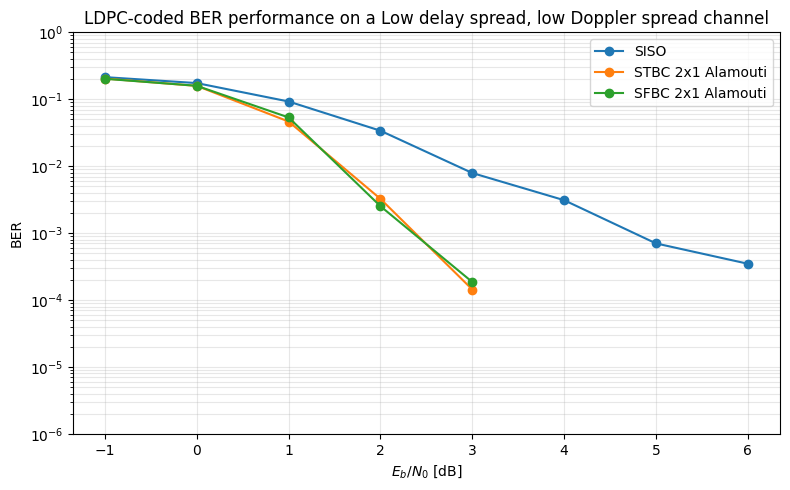

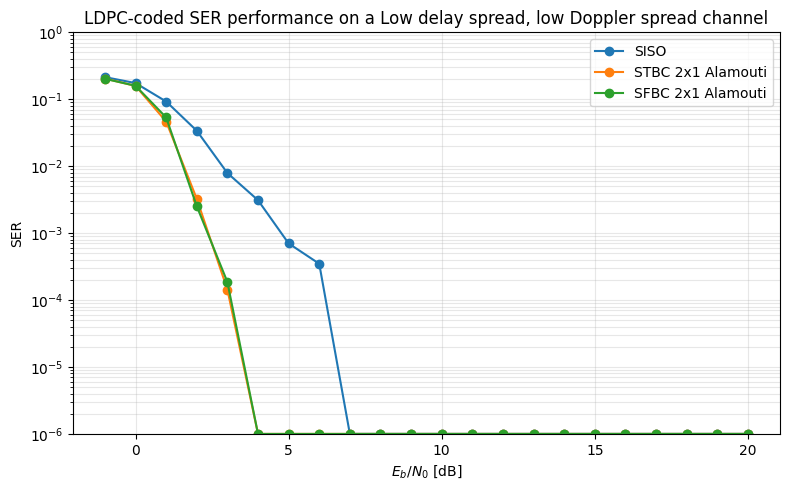

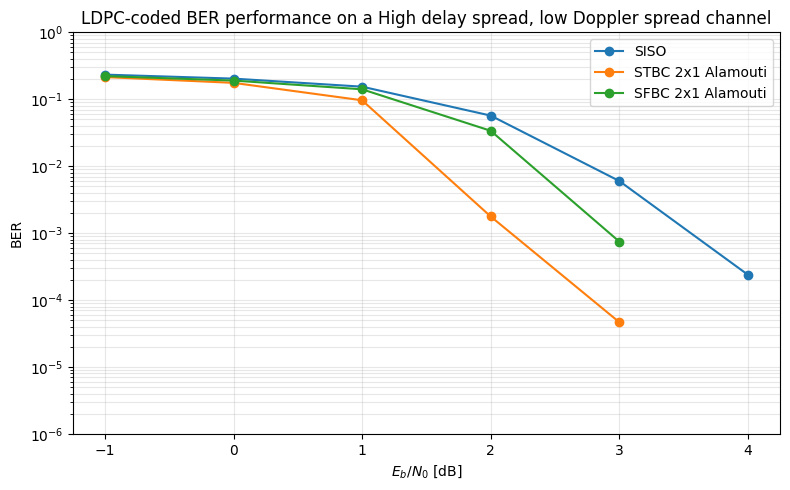

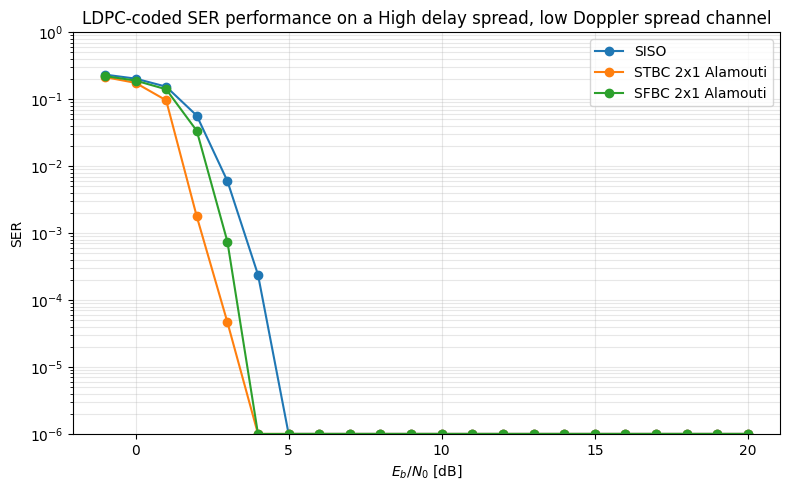

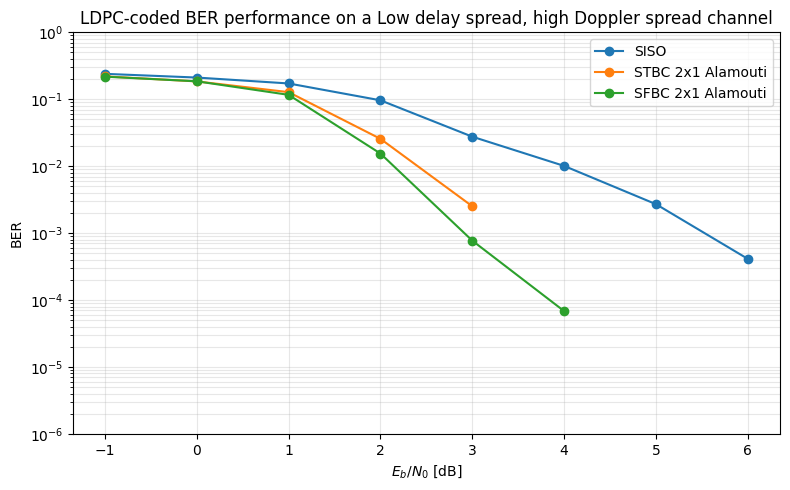

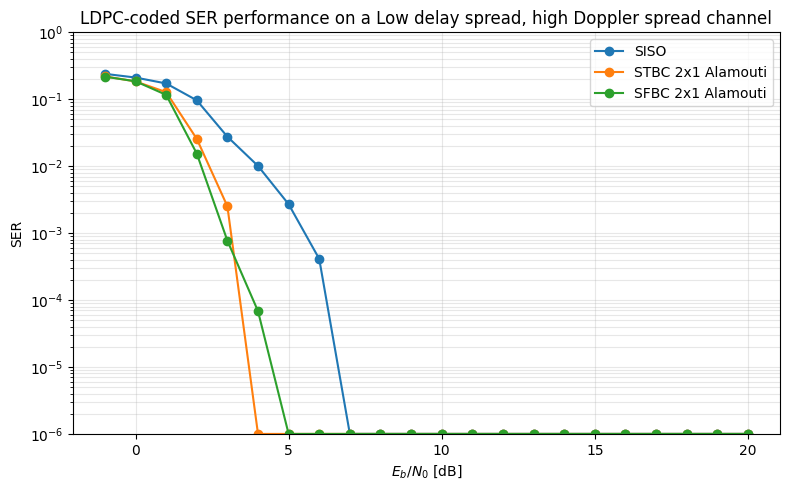

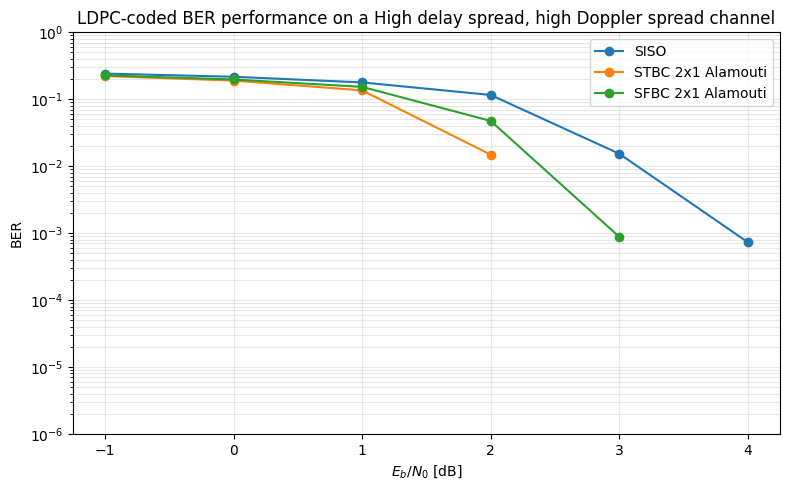

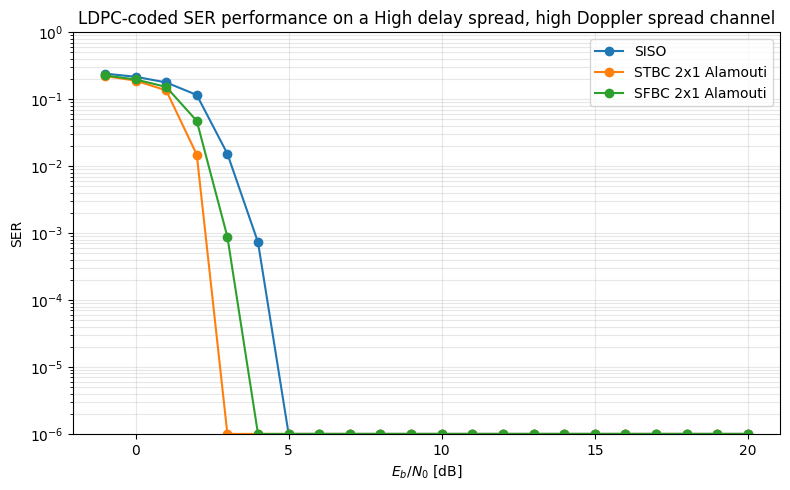

,case,scheme,min_ber,avg_ber_std,min_ser,avg_ser_std,bits_per_trial,symbols_per_trial,mc_trials
0,High Delay High Doppler,SFBC 2x1 Alamouti,0.0,0.000223,0.0,0.000223,1048576,1048576,3
1,High Delay High Doppler,SISO,0.0,0.000463,0.0,0.000463,1048576,1048576,3
2,High Delay High Doppler,STBC 2x1 Alamouti,0.0,0.000152,0.0,0.000152,1048576,1048576,3
3,High Delay Low Doppler,SFBC 2x1 Alamouti,0.0,0.000214,0.0,0.000214,1048576,1048576,3
4,High Delay Low Doppler,SISO,0.0,0.000320,0.0,0.000320,1048576,1048576,3
5,High Delay Low Doppler,STBC 2x1 Alamouti,0.0,0.000294,0.0,0.000294,1048576,1048576,3
6,Low Delay High Doppler,SFBC 2x1 Alamouti,0.0,0.000297,0.0,0.000297,1048576,1048576,3
7,Low Delay High Doppler,SISO,0.0,0.000969,0.0,0.000969,1048576,1048576,3
8,Low Delay High Doppler,STBC 2x1 Alamouti,0.0,0.000396,0.0,0.000396,1048576,1048576,3
9,Low Delay Low Doppler,SFBC 2x1 Alamouti,0.0,0.000158,0.0,0.000158,1048576,1048576,3


In [78]:
def enforce_zero_tail(metric_values):
    values = np.asarray(metric_values, dtype=np.float64).copy()
    zero_indices = np.where(values <= 0.0)[0]
    if zero_indices.size > 0:
        values[zero_indices[0]:] = 0.0
    return values


ldpc_plot_results_by_case = {}

for case_name, case_results in ldpc_results_by_case.items():
    plot_case_results = {}
    plot_case_results_for_display = {}
    for scheme_name, result_df in case_results.items():
        plot_df = result_df.copy()
        plot_df["ber"] = enforce_zero_tail(plot_df["ber"].to_numpy())
        if scheme_name == "STBC 2x1 Alamouti":
            plot_df.loc[plot_df["ebno_db"] > 15.0, "ber"] = 0.0
        plot_df["ber"] = enforce_zero_tail(plot_df["ber"].to_numpy())
        plot_df.loc[plot_df["ber"] <= 0.0, "ber_std"] = 0.0
        plot_df["ser"] = plot_df["ber"]
        plot_df["ser_std"] = plot_df["ber_std"]
        plot_case_results[scheme_name] = plot_df

        display_df = plot_df.copy()
        display_df["ser"] = display_df["ser"].mask(display_df["ser"] <= 0.0, 1e-6)
        plot_case_results_for_display[scheme_name] = display_df

    ldpc_plot_results_by_case[case_name] = plot_case_results
    plot_case_metric_curves(case_name, plot_case_results, "ber", ldpc_coded=True)
    plot_case_metric_curves(case_name, plot_case_results_for_display, "ser", ldpc_coded=True)

ldpc_plot_all_results_df = pd.concat(
    [
        result_df
        for case_results in ldpc_plot_results_by_case.values()
        for result_df in case_results.values()
    ],
    ignore_index=True,
)

ldpc_summary_table = ldpc_plot_all_results_df.groupby(["case", "scheme"], as_index=False).agg(
    min_ber=("ber", "min"),
    avg_ber_std=("ber_std", "mean"),
    min_ser=("ser", "min"),
    avg_ser_std=("ser_std", "mean"),
    bits_per_trial=("total_bits_per_trial", "max"),
    symbols_per_trial=("total_symbols_per_trial", "max"),
    mc_trials=("mc_trials", "max"),
)

display(ldpc_summary_table)